## MAE comparison: iid vs compression

In [ ]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
german_sizes = [8, 16, 24, 32, 40]
compas_sizes = [24, 32, 64, 96, 128, 160]
times_iid_info_path_german = {}
times_iid_info_path_compas = {}
for size in german_sizes:
    times_iid_info_path_german[size] = f'../metadata/iid_runs/german/{size}/cte_shap_sage_times_0_3.csv'

for size in compas_sizes:
    times_iid_info_path_compas[size] = f'../metadata/iid_runs/compas/{size}/cte_shap_sage_times_0_3.csv'

### load iid data (mae)

In [31]:
times_iid_info_german = pd.concat(
    [pd.read_csv(path) for path in times_iid_info_path_german.values()],
    ignore_index=True
)

print(times_iid_info_german.tail())

   dataset  repeat    method  time_explanation  time_sample_choose  \
25  german       0  iid_sage        410.806267            0.000316   
26  german       1  iid_shap        115.010240            0.000054   
27  german       1  iid_sage        487.012206            0.000054   
28  german       2  iid_shap        114.535302            0.000057   
29  german       2  iid_sage        463.093497            0.000057   

    n_original  n_sample       mmd       mae  top_k  
25         200        40  0.001817  0.001974    0.4  
26         200        40  0.002713  0.005570    0.4  
27         200        40  0.002713  0.003523    0.6  
28         200        40  0.001809  0.005132    0.2  
29         200        40  0.001809  0.003652    0.8  


In [68]:
times_iid_info_german_grouped = times_iid_info_german.groupby(['method', 'n_sample'])['mae'].agg(['mean', 'std']).reset_index()
print(times_iid_info_german_grouped)

     method  n_sample      mean       std
0  iid_sage         8  0.014303  0.001497
1  iid_sage        16  0.007069  0.001032
2  iid_sage        24  0.005074  0.001426
3  iid_sage        32  0.004890  0.000811
4  iid_sage        40  0.003050  0.000934
5  iid_shap         8  0.010909  0.001901
6  iid_shap        16  0.008139  0.000578
7  iid_shap        24  0.006888  0.000426
8  iid_shap        32  0.005947  0.000593
9  iid_shap        40  0.005388  0.000228


In [69]:
# agg_cols = ['time_explanation', 'time_sample_choose', 'mmd', 'mae', 'top_k']
# times_iid_info_german_grouped = (
#     times_iid_info_german
#     .groupby(['method', 'n_sample'])
#     [agg_cols]
#     .mean()
#     .reset_index()
# )
# print(times_iid_info_german_grouped)

In [88]:
times_iid_info_compas = pd.concat(
    [pd.read_csv(path) for path in times_iid_info_path_compas.values()],
    ignore_index=True
)
times_iid_info_compas_grouped = times_iid_info_compas.groupby(['method', 'n_sample'])['mae'].agg(['mean', 'std']).reset_index()

### load cte data (mae)

In [70]:
times_cte_info_path_german = f'../metadata/german/cte_shap_sage_times_0_3.csv'
times_cte_info_german = pd.read_csv(times_cte_info_path_german)
# times_cte_info_german_grouped = (
#     times_cte_info_german
#     .groupby(['method', 'n_sample'])
#     [agg_cols]
#     .mean()
#     .reset_index()
# )
times_cte_info_german_grouped = times_cte_info_german.groupby(['method', 'n_sample'])['mae'].agg(['mean', 'std']).reset_index()
times_cte_info_german_grouped = times_cte_info_german_grouped[
    ~times_cte_info_german_grouped['method'].isin(['iid_shap', 'iid_sage'])
]
print(times_cte_info_german_grouped)

                      method  n_sample      mean       std
0                   cte_sage         8  0.009344  0.002312
1                   cte_shap         8  0.008265  0.000879
2   cte_stratified_pred_sage        12  0.005315  0.001001
3   cte_stratified_pred_shap        12  0.007599  0.001095
4   cte_stratified_real_sage        12  0.006365  0.000311
5   cte_stratified_real_shap        12  0.007469  0.000471
6  cte_with_predictions_sage         8  0.009625  0.002245
7  cte_with_predictions_shap         8  0.007832  0.000648


In [89]:
times_cte_info_path_compas = f'../metadata/compas/cte_shap_sage_times_0_3.csv'
times_cte_info_compas = pd.read_csv(times_cte_info_path_compas)
times_cte_info_compas_grouped = times_cte_info_compas.groupby(['method', 'n_sample'])['mae'].agg(['mean', 'std']).reset_index()
times_cte_info_compas_grouped = times_cte_info_compas_grouped[
    ~times_cte_info_compas_grouped['method'].isin(['iid_shap', 'iid_sage'])
]

### visualizations

In [85]:
def visualize(dataset_name, data_iid, data_cte, explanation):
    fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
    iid_df = data_iid[data_iid['method'].str.endswith(f'_{explanation}')]
    iid_mae = iid_df['mean'].tolist()
    iid_size = iid_df['n_sample'].tolist()
    iid_yerr = iid_df['std'].tolist()
    
    ax.errorbar(
        x=iid_size, y=iid_mae, yerr=iid_yerr,
        fmt='o-', color='royalblue', label='IID', markersize=8,  capsize=5, linewidth=2
    )
    sage_df = data_cte[data_cte['method'].str.endswith(f'_{explanation}')]
    for method in sage_df['method'].unique():
        method_data = sage_df[sage_df['method'] == method]
        x = method_data['n_sample']
        y = method_data['mean']
        yerr = method_data['std']
        ax.errorbar(
            x=x, y=y, yerr=yerr,
            fmt='o-', label=method.replace(f'_{explanation}', ''), 
            markersize=8, capsize=5, linewidth=2
        )
    step = iid_size[1] - iid_size[0]
    xticks = list(range(min(iid_size), max(iid_size) + step, step))
    ax.set_xticks(xticks)

    ax.set_xlabel("N Samples")
    ax.set_ylabel("MAE")
    ax.set_title(f"{dataset_name}: {explanation.upper()} MAE vs N Samples")
    ax.legend()
    ax.grid(True, linestyle='dotted', alpha=0.7)
    plt.tight_layout()
    plt.show()


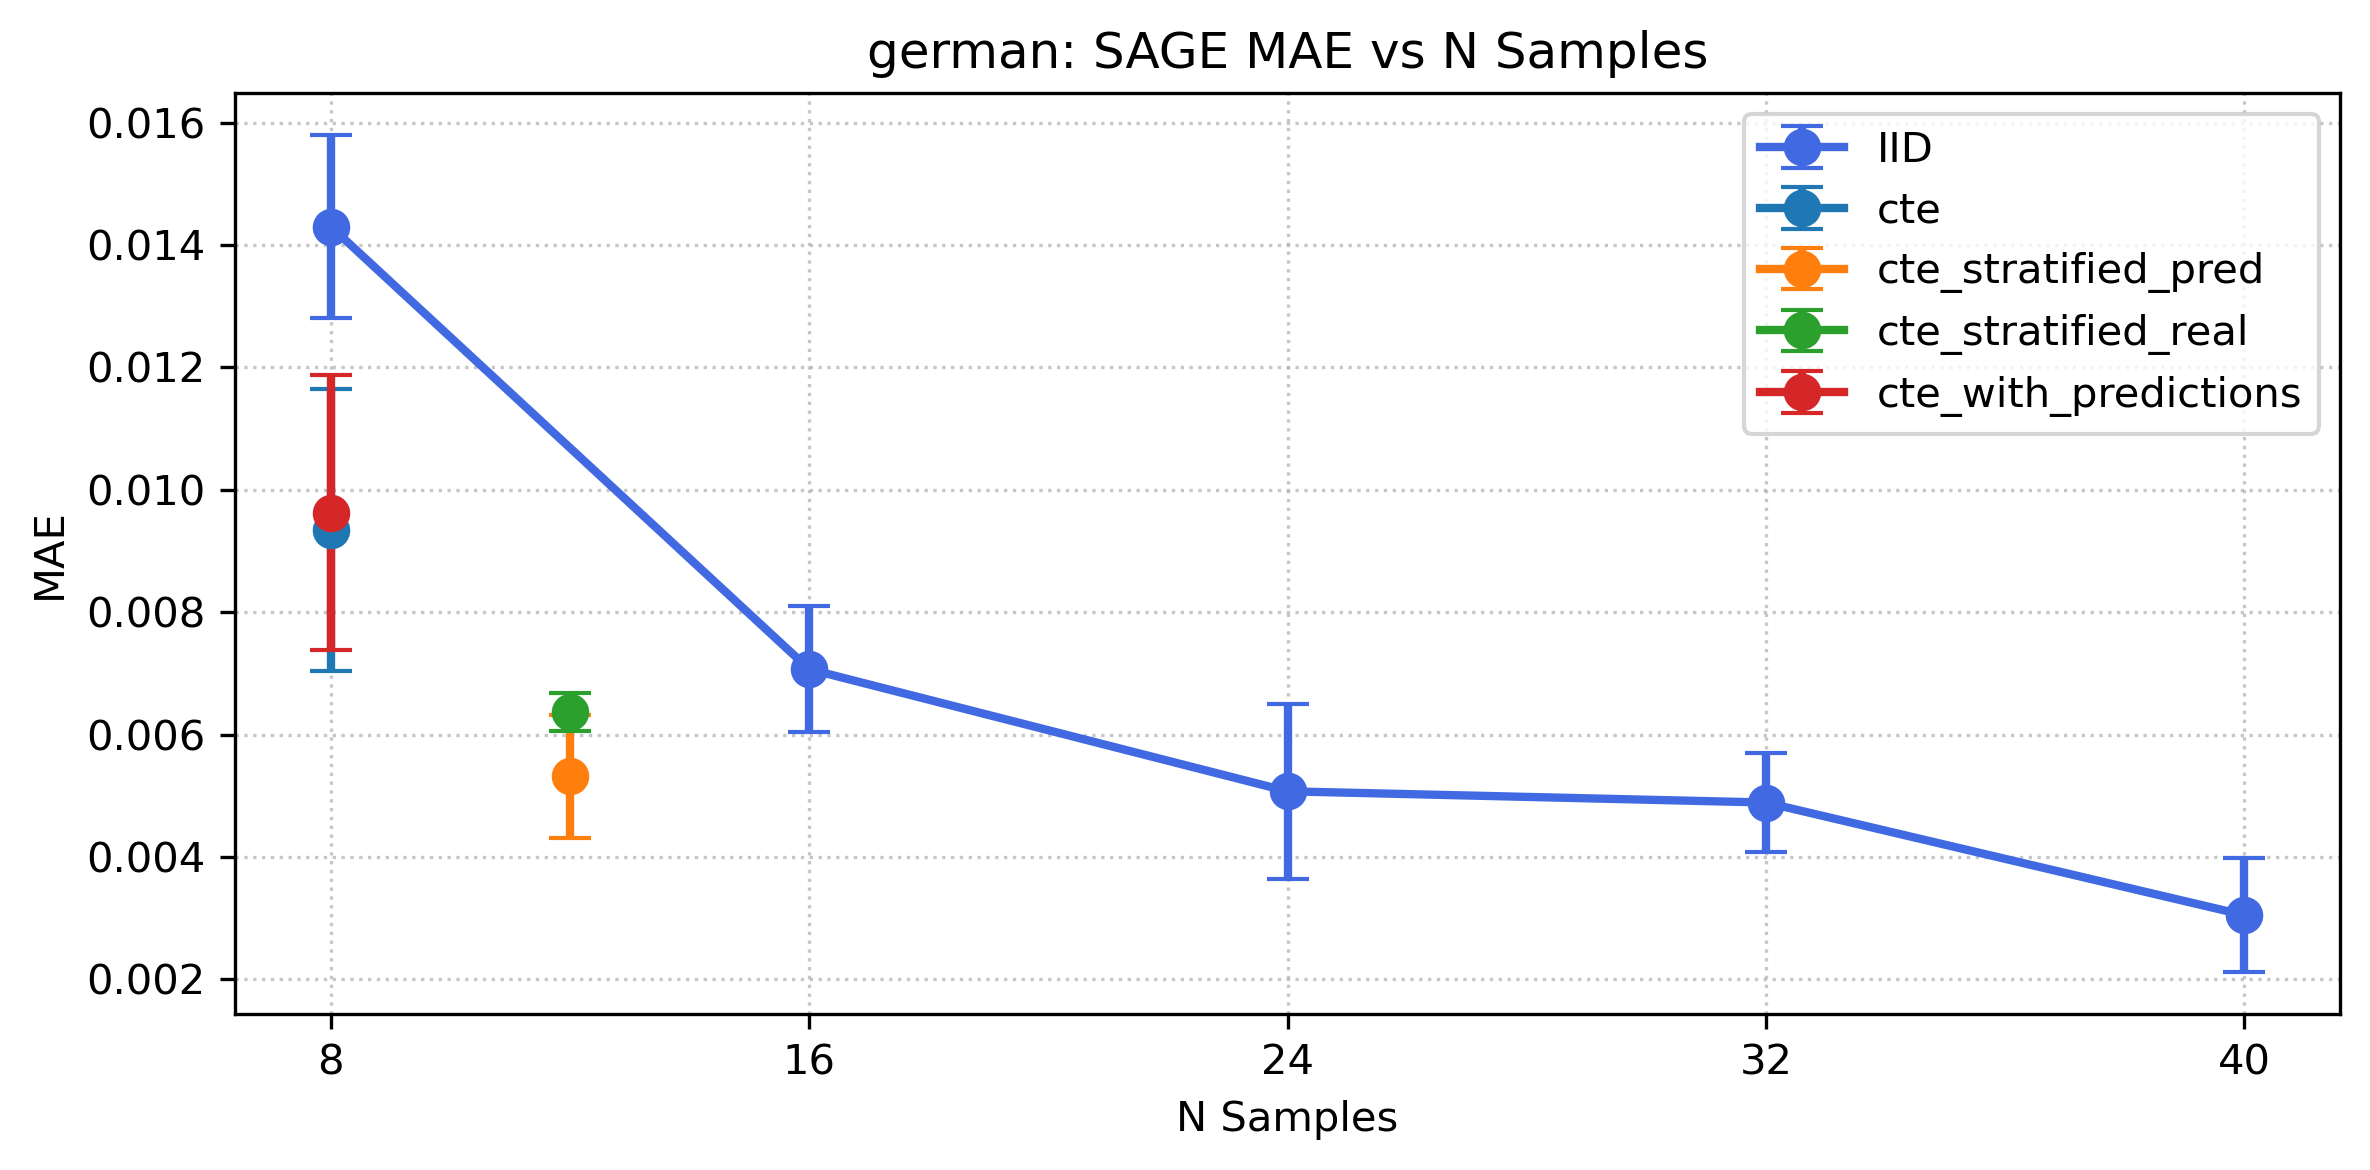

In [86]:
visualize("german", times_iid_info_german_grouped, times_cte_info_german_grouped, 'sage')

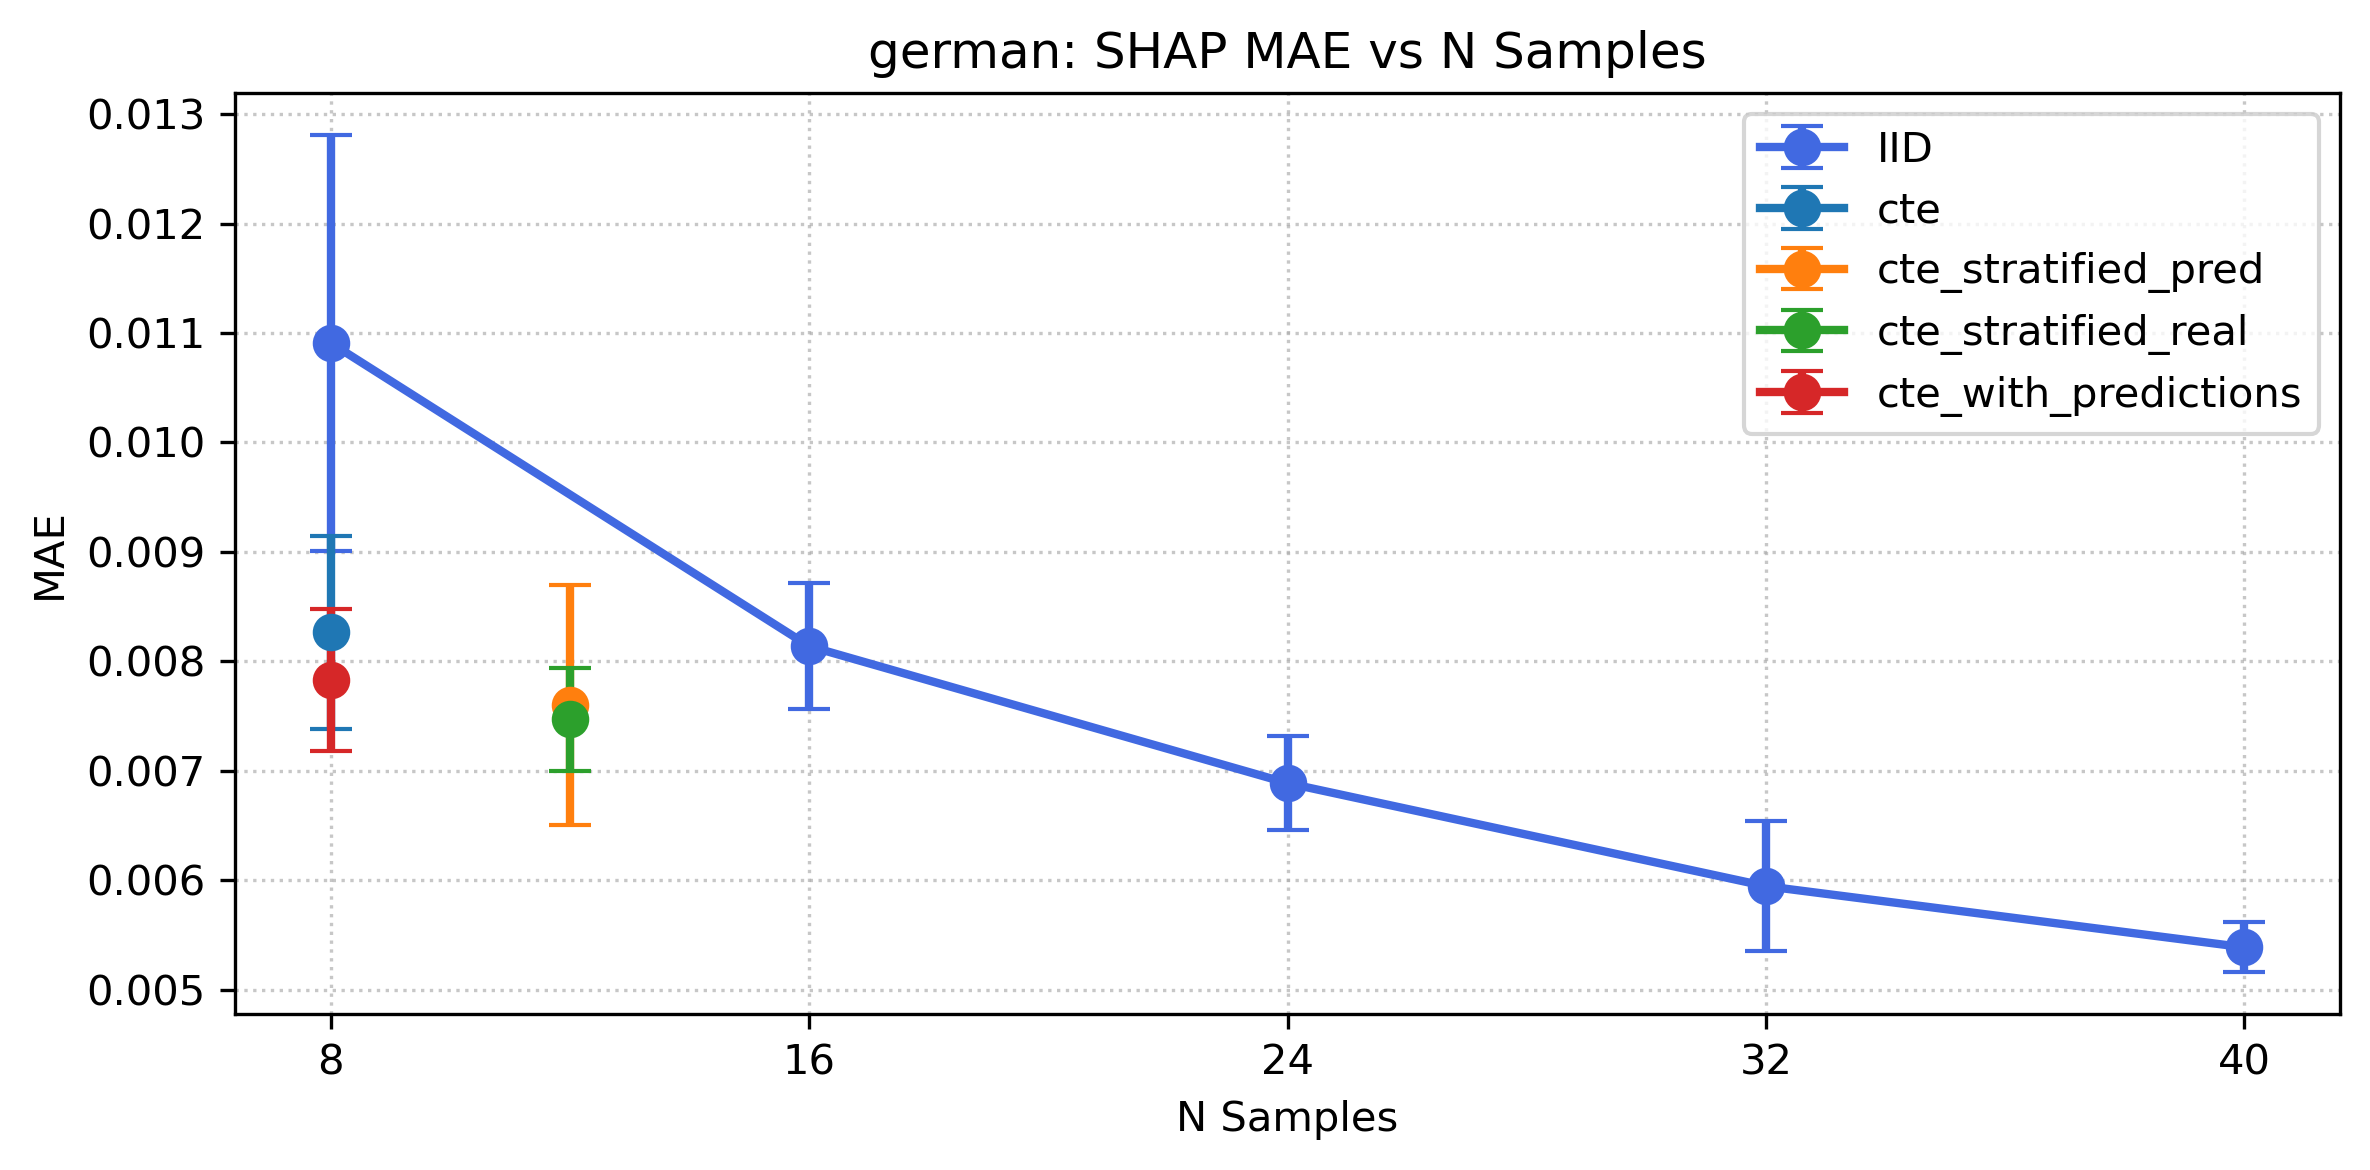

In [87]:
visualize("german", times_iid_info_german_grouped, times_cte_info_german_grouped, 'shap')

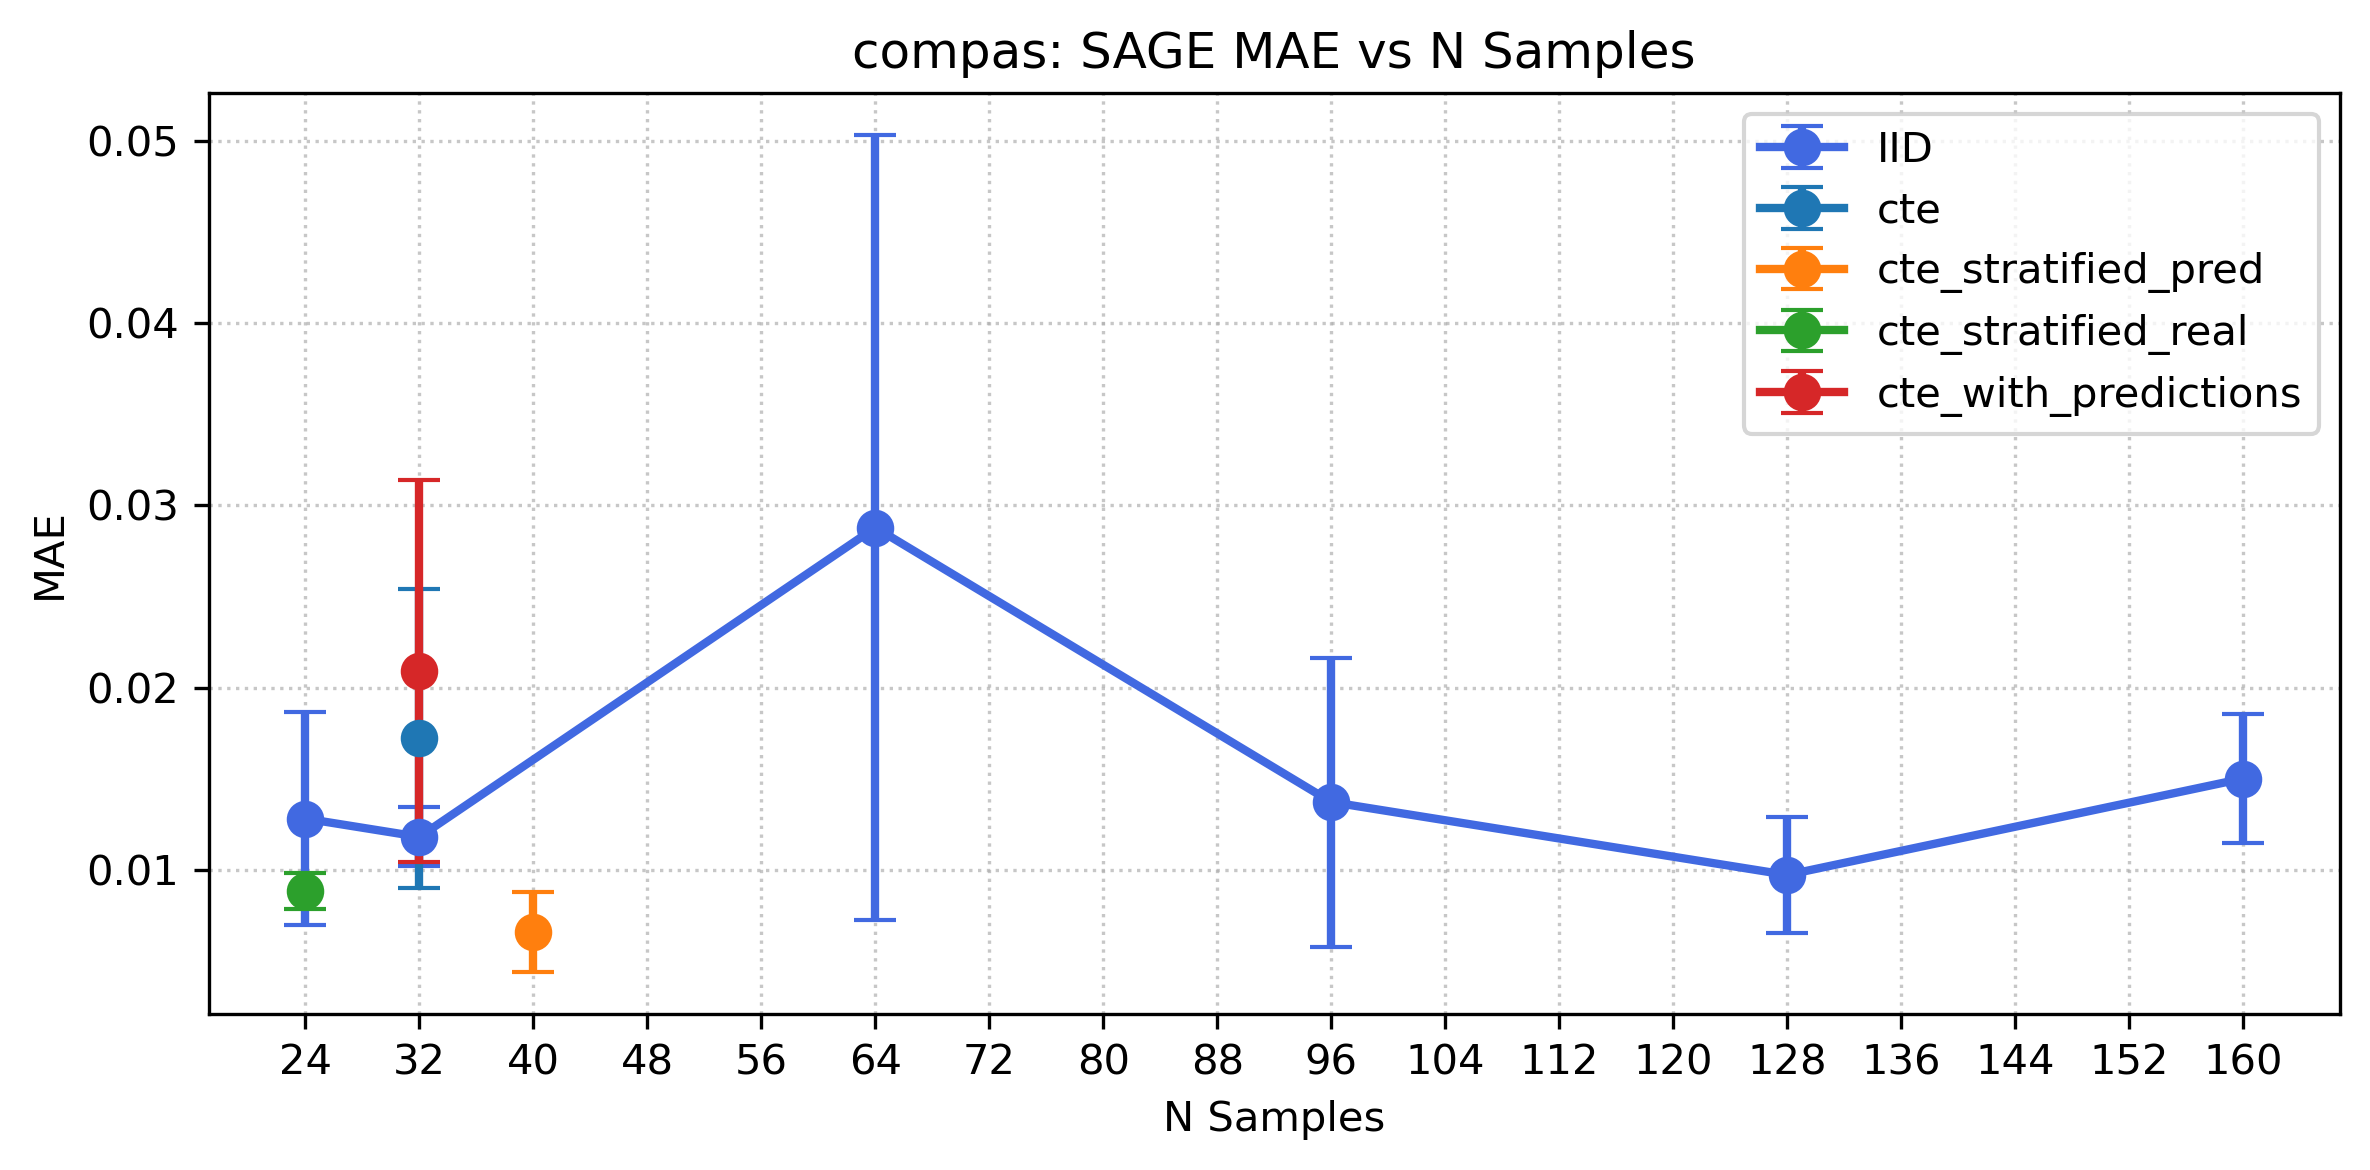

In [92]:
visualize("compas", times_iid_info_compas_grouped, times_cte_info_compas_grouped, 'sage')

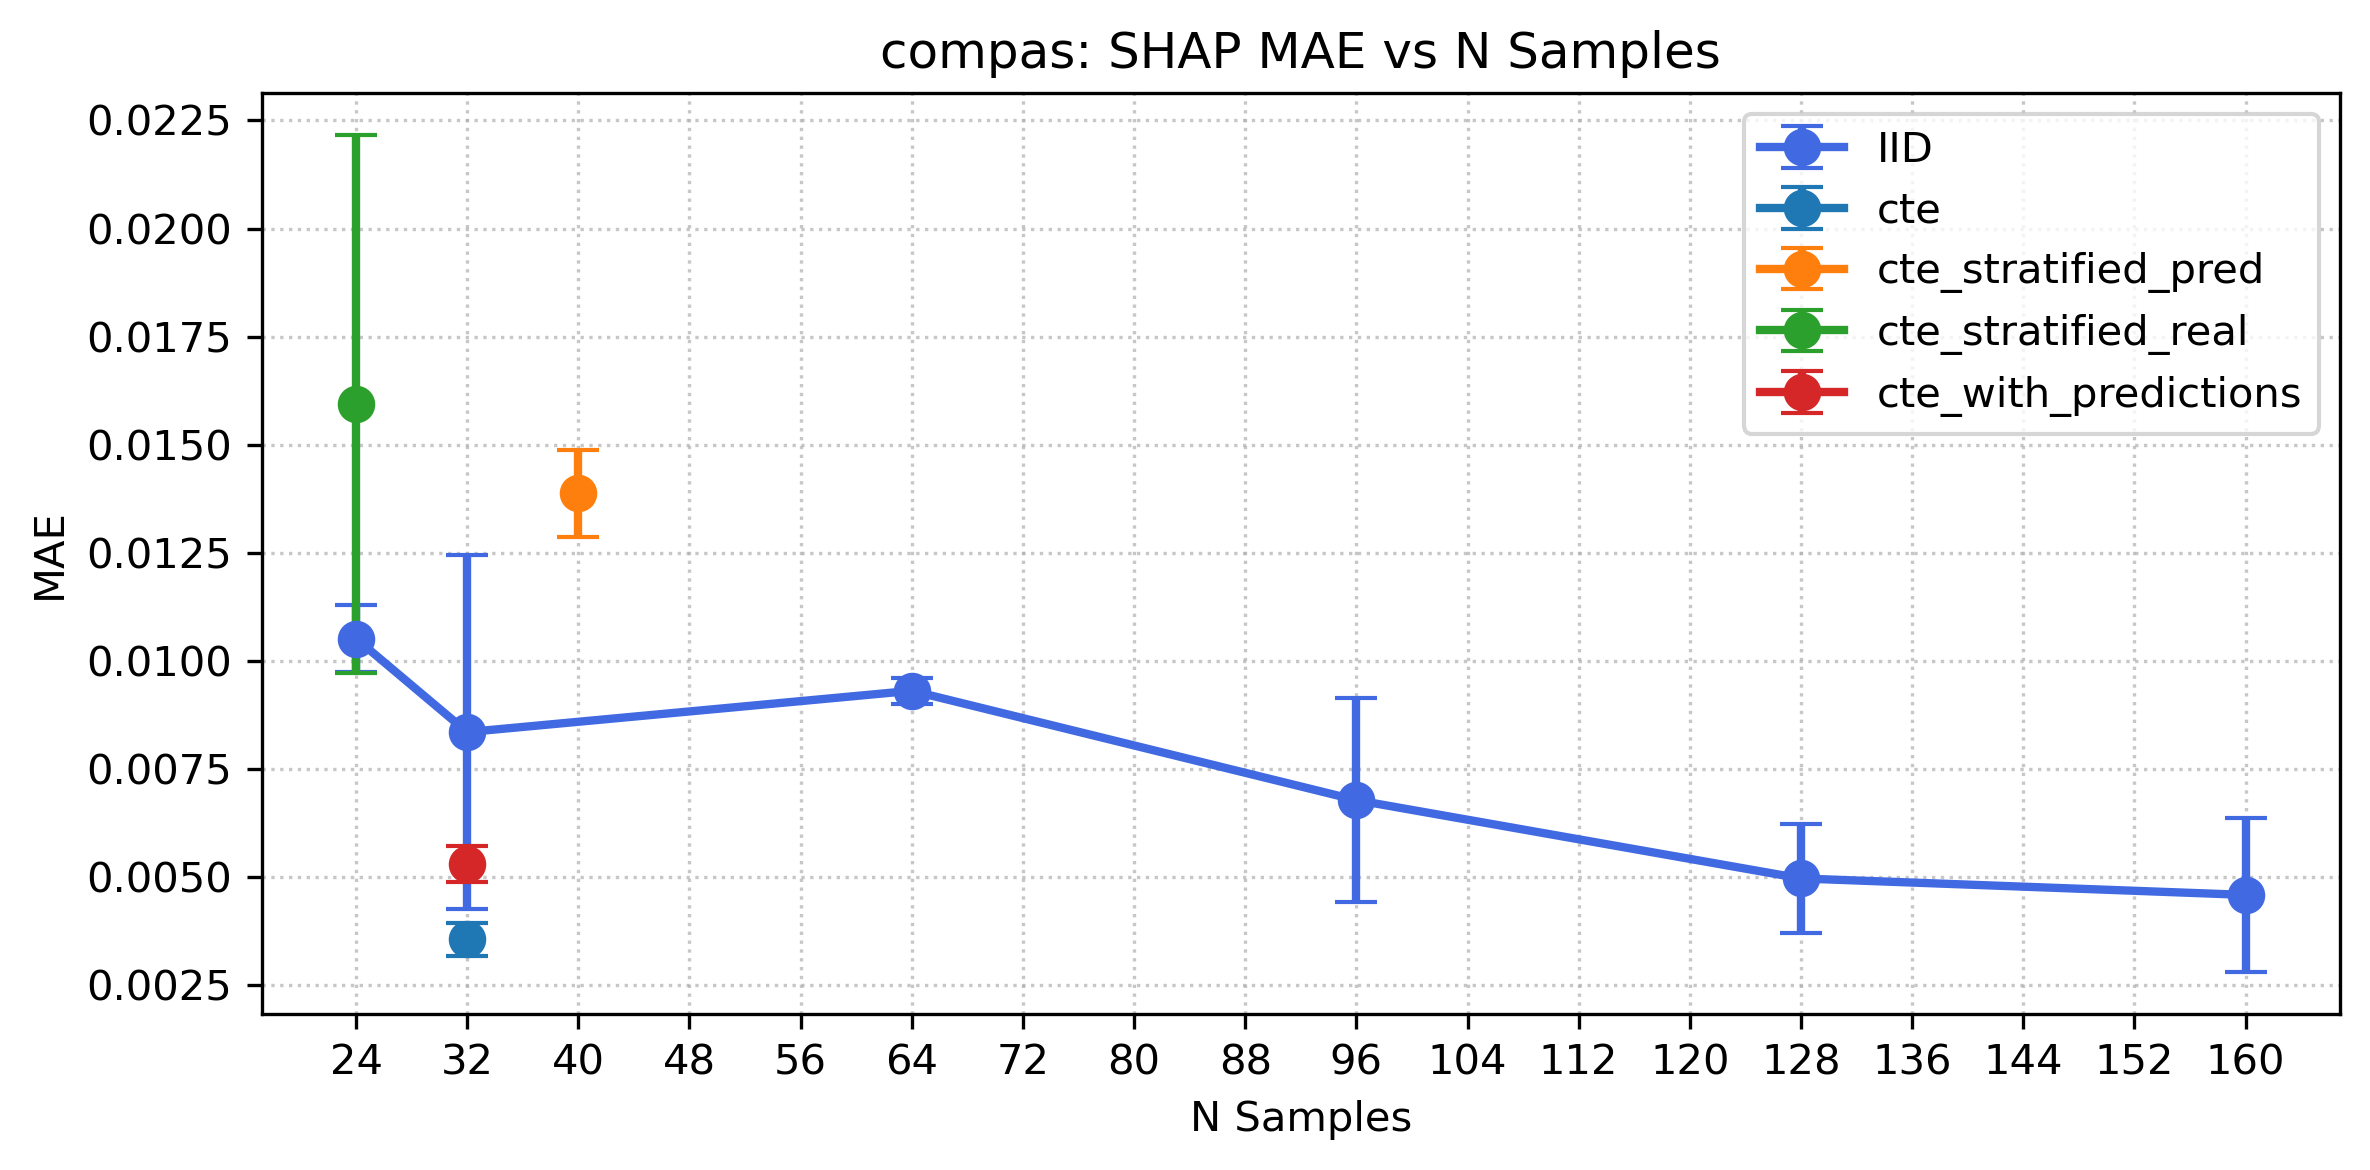

In [93]:
visualize("compas", times_iid_info_compas_grouped, times_cte_info_compas_grouped, 'shap')